# How much will it move, and how bad could a bad day be?

**In short.** Which way a price goes next cannot be told from its past. How *much* it
moves can: rough days follow rough days. A forecast built from three numbers (how
rough the last day, week and month were) beats every alternative tried here, and a
loss limit that is scaled by that forecast is broken about as often as it says it
will be. The tables at the end of each part say where that fails.

| Step | What it does | Code | Screen in the app |
|---|---|---|---|
| 1 | Forecasts the size of the next day's and week's movement | `radar.models.volatility` | Daily movement |
| 2 | Turns that into a loss limit and counts how often it was broken | `radar.models.tail_risk` | Possible loss |

Every forecast shown was made from prices up to its own day, by a model fitted on
earlier days only, then compared with what happened next.

Rebuild with `uv run python backend/scripts/build_notebooks.py 03_swings_and_loss`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import select

from radar.db.models import RiskMetric, VolatilityForecast
from radar.db.session import make_engine, session_scope
from radar.models import volatility
from radar.notebooks import ACCENT, BAD, GOOD, INK, MUTED, use_style
from radar.pipelines import risk as risk_job
from radar.pipelines import volatility as volatility_job
from radar.pipelines.datasets import build_regime_observations
from radar.universe import get_universe

use_style()
engine, universe = make_engine(), get_universe()
MARKETS = {asset.symbol: asset.name for asset in universe.primary}
METHODS = {
    "har": "last day, week, month",
    "gbt": "tree model",
    "carry": "yesterday repeated",
    "regime": "average for the market's state",
}
LIMITS = {
    "historical": "past losses as they were",
    "filtered": "past losses scaled to the forecast",
    "simulator": "read off the simulation",
}

with session_scope(engine) as session:
    forecasts = pd.read_sql(select(VolatilityForecast), session.connection())
    risk = pd.read_sql(select(RiskMetric), session.connection())
    swing_scores = {
        s: volatility_job.current_model(session, s).metrics["horizons"] for s in MARKETS
    }
    swing_weights = {s: volatility_job.current_model(session, s).params for s in MARKETS}
    limit_scores = {s: risk_job.current_model(session, s).metrics for s in MARKETS}
    first = next(iter(MARKETS))
    example = build_regime_observations(session, universe.get(first))

for symbol, name in MARKETS.items():
    days = forecasts[(forecasts["symbol"] == symbol) & (forecasts["horizon_days"] == 1)]
    print(f"{name}: {days['ts'].nunique():,} days forecast, from {days['ts'].min():%Y-%m-%d}")

Bitcoin: 1,604 days forecast, from 2022-05-18
Gold: 1,431 days forecast, from 2022-06-25
US stocks (S&P 500): 2,204 days forecast, from 2017-12-28


## Step 1. The size of the next movement

### The three inputs

The size of tomorrow's movement looks like a blend of how rough **yesterday** was, how
rough the **last week** was, and how rough the **last month** was. The forecast is a
plain regression on those three numbers (known as HAR).

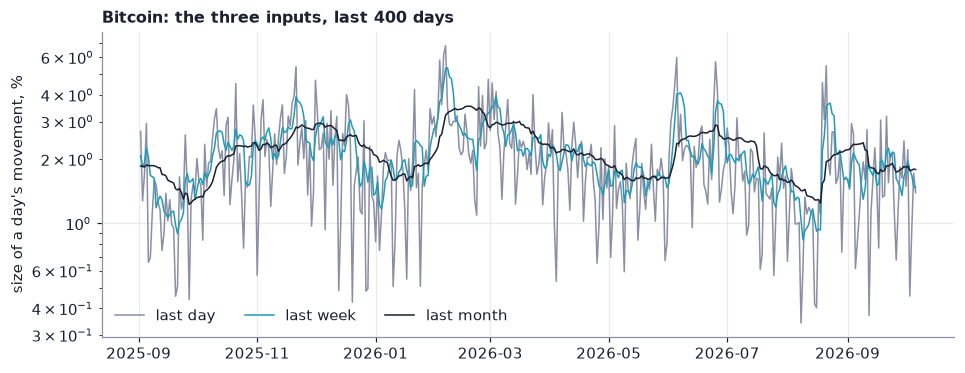

In [2]:
inputs = volatility.har_features(example["rv"]).dropna().iloc[-400:]
fig, ax = plt.subplots()
for column, label, colour in (
    ("log_day", "last day", MUTED),
    ("log_week", "last week", ACCENT),
    ("log_month", "last month", INK),
):
    ax.plot(inputs.index, np.exp(inputs[column]) * 100, label=label, color=colour, lw=1)
ax.set(
    title=f"{MARKETS[first]}: the three inputs, last {len(inputs)} days",
    ylabel="size of a day's movement, %",
    yscale="log",
)
ax.legend(ncol=3);

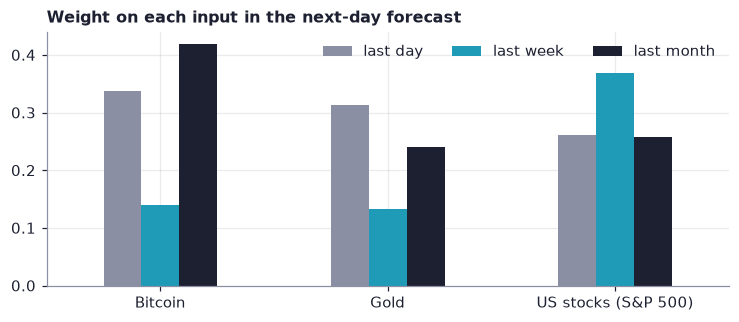

In [3]:
# How much weight the fitted forecast puts on each input, for the next day.
weights = pd.DataFrame(
    {MARKETS[s]: swing_weights[s]["1"]["coefficients"] for s in MARKETS}
).T.rename(columns={"log_day": "last day", "log_week": "last week", "log_month": "last month"})
ax = weights[["last day", "last week", "last month"]].plot.bar(
    rot=0, color=[MUTED, ACCENT, INK], figsize=(8, 3)
)
ax.set(title="Weight on each input in the next-day forecast", xlabel="")
ax.legend(ncol=3);

### The forecast beside what happened

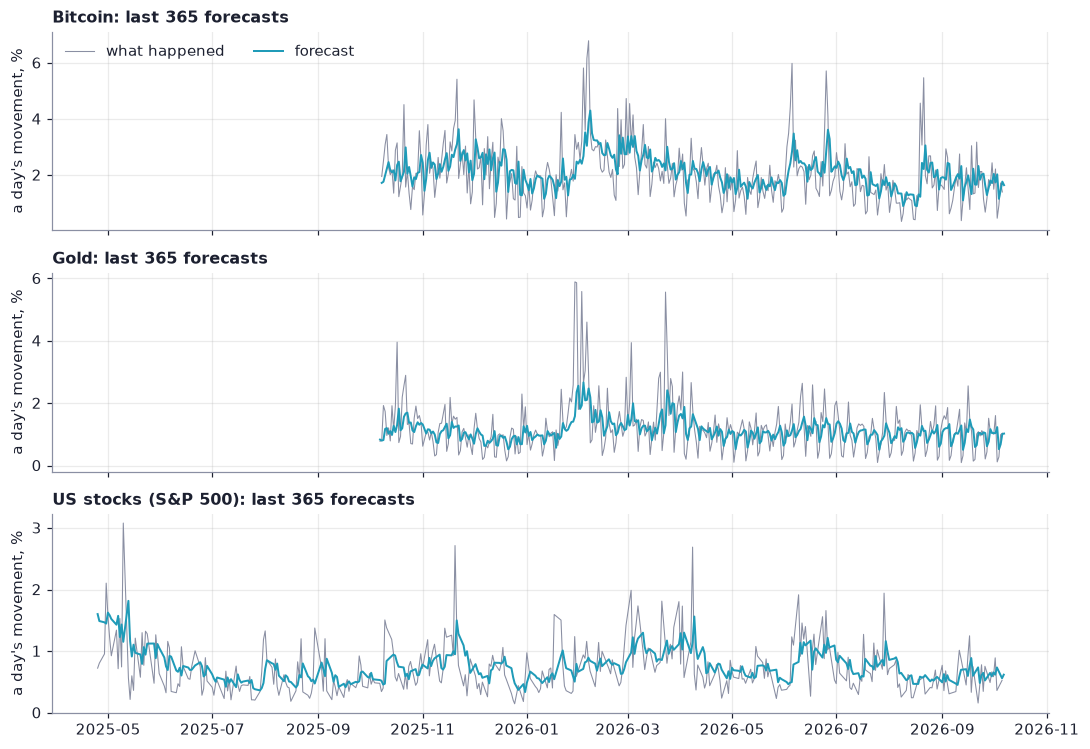

In [4]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(10, 2.3 * len(MARKETS)), sharex=True)
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    part = forecasts[
        (forecasts["symbol"] == symbol)
        & (forecasts["horizon_days"] == 1)
        & (forecasts["model"] == "har")
    ].sort_values("ts").iloc[-365:]
    ax.plot(part["ts"], part["realised"] * 100, color=MUTED, lw=0.7, label="what happened")
    ax.plot(part["ts"], part["forecast"] * 100, color=ACCENT, lw=1.3, label="forecast")
    ax.set(title=f"{name}: last {len(part)} forecasts", ylabel="a day's movement, %")
axes[0].legend(ncol=2)
fig.tight_layout()

### Is it better than the alternatives?

Four methods are scored on the same days, none of which the method had seen. The
score is a standard forecast error for movement size (QLIKE): 0 is perfect and lower
is better. The last column asks whether a method's gap to the three-input forecast
could be luck (Diebold-Mariano test): under 0.05, it is not.

In [5]:
rows = []
for symbol, name in MARKETS.items():
    for horizon, evaluation in swing_scores[symbol].items():
        for score in evaluation["scores"]:
            rows.append(
                {
                    "market": name,
                    "days ahead": int(horizon),
                    "days tested": evaluation["n"],
                    "method": METHODS[score["model"]],
                    "error": score["qlike"],
                    "gap could be luck (p)": score.get("dm_p_value_vs_har"),
                    "shown in the app": score["model"] == evaluation["shown"],
                }
            )
scores = pd.DataFrame(rows).set_index(["market", "days ahead", "method"])
scores

days tested  error  gap could be luck (p)  \
market              days ahead method                                                                      
Bitcoin             1          last day, week, month                  1603   0.47                    NaN   
                               tree model                             1603   0.57                   0.00   
                               yesterday repeated                     1603   0.92                   0.00   
                               average for the market's state         1603   0.53                   0.00   
                    7          last day, week, month                  1597   0.19                    NaN   
                               tree model                             1597   0.21                   0.26   
                               yesterday repeated                     1597   1.33                   0.00   
                               average for the market's state         1597   0.25                   0.00   
Gold                1          last day, week, month                  1430   0.57                    NaN   
                               tree model                             1430   0.67                   0.00   
                               yesterday repeated                     1430   0.98                   0.00   
                               average for the market's state         1430   0.79                   0.09   
                    7          last day, week, month                  1424   0.42                    NaN   
                               tree model                             1424   0.50                   0.06   
                               yesterday repeated                     1424   1.88                   0.00   
                               average for the market's state         1424   0.50                   0.00   
US stocks (S&P 500) 1          last day, week, month                  2203   0.49                    NaN   
                               tree model                             2203   0.67                   0.00   
                               yesterday repeated                     2203   0.87                   0.00   
                               average for the market's state         2203   0.76                   0.00   
                    7          last day, week, month                  2199   0.33                    NaN   
                               tree model                             2199   0.49                   0.00   
                               yesterday repeated                     2199   0.90                   0.00   
                               average for the market's state         2199   0.58                   0.01   

                                                               shown in the app  
market              days ahead method                                            
Bitcoin             1          last day, week, month                       True  
                               tree model                                 False  
                               yesterday repeated                         False  
                               average for the market's state             False  
                    7          last day, week, month                       True  
                               tree model                                 False  
                               yesterday repeated                         False  
                               average for the market's state             False  
Gold                1          last day, week, month                       True  
                               tree model                                 False  
                               yesterday repeated                         False  
                               average for the market's state             False  
                    7          last day, week, month                       True  
                        

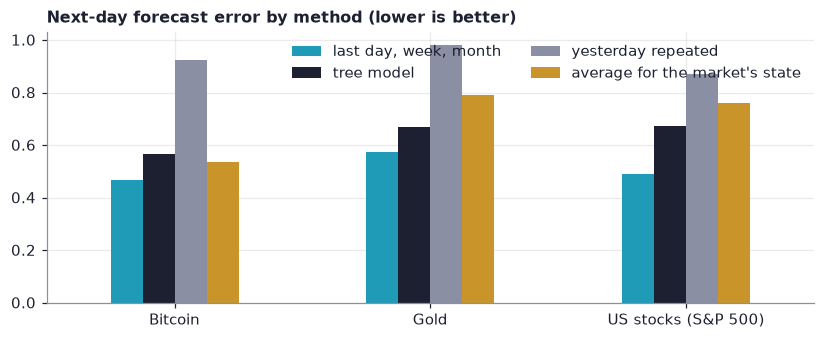

In [6]:
next_day = scores.xs(1, level="days ahead")["error"].unstack("method")[list(METHODS.values())]
ax = next_day.loc[list(MARKETS.values())].plot.bar(
    rot=0, color=[ACCENT, INK, MUTED, "#c9952b"], figsize=(9, 3.2)
)
ax.set(title="Next-day forecast error by method (lower is better)", xlabel="")
ax.legend(ncol=2);

In [7]:
# The claim in the summary, checked on the table rather than by eye.
best = scores["error"].groupby(level=["market", "days ahead"]).idxmin().map(lambda key: key[2])
print(best.value_counts().rename("times it had the lowest error").to_string())
shown = scores[scores["shown in the app"]].reset_index()["method"].value_counts()
print("\nshown in the app:", shown.to_dict())

error
last day, week, month    6

shown in the app: {'last day, week, month': 6}


**What this says.** The count above is the result: the method with the lowest error
in each market and horizon, and the one the app shows. The tree model sees the same
three numbers plus the market's state and does not do better for it. News tone was
tested as a further input in a separate, pre-written test and gave no gain in any of
twelve comparisons (`07_what_we_tested`), so it is not in the forecast.

## Step 2. A loss limit, and how often it was broken

- **Loss limit (95%)**: the loss that should be exceeded on only 1 day in 20. Known
  as Value at Risk.
- **Average loss beyond it**: how bad the days past the limit were, on average. Known
  as expected shortfall.

Three ways of setting the limit are compared.

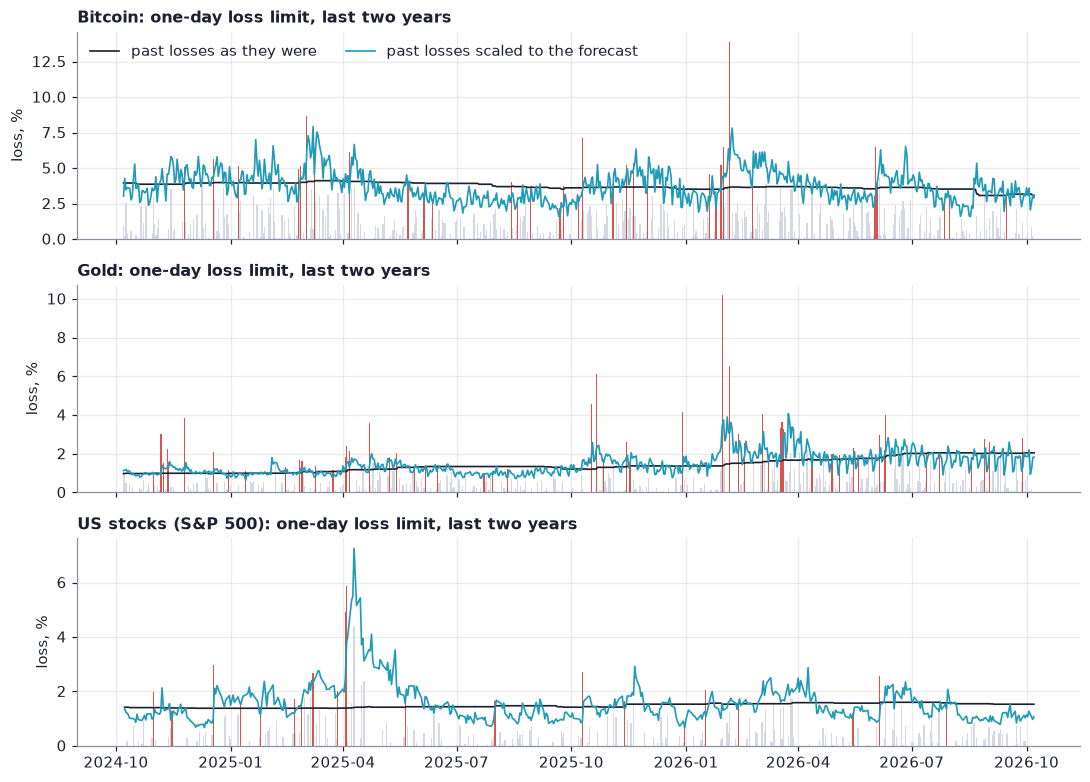

In [8]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(10, 2.4 * len(MARKETS)), sharex=True)
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    part = risk[
        (risk["symbol"] == symbol) & (risk["horizon_days"] == 1) & (risk["level"] == 0.95)
    ].sort_values("ts")
    recent = part[part["ts"] >= part["ts"].max() - pd.Timedelta(days=730)]
    scaled = recent[recent["method"] == "filtered"]
    lost = scaled["realised_loss"].clip(lower=0) * 100
    broke = scaled["realised_loss"] > scaled["var"]
    ax.bar(scaled["ts"], lost, color=np.where(broke, BAD, "#d5d8e2"), width=1)
    for method, colour in (("historical", INK), ("filtered", ACCENT)):
        line = recent[recent["method"] == method]
        ax.plot(line["ts"], line["var"] * 100, color=colour, lw=1.1, label=LIMITS[method])
    ax.set(title=f"{name}: one-day loss limit, last two years", ylabel="loss, %")
axes[0].legend(ncol=2)
fig.tight_layout()

Grey bars are the losses that followed. A red bar is a day that lost more than the
scaled limit said it should. The scaled limit moves with the market; the unscaled one
reacts slowly.

### Counting the broken limits

A 95% limit should be broken about 5 days in 100. The table counts how often each was
broken, how often it should have been, and whether the gap is too large to be luck
(Kupiec's test: under 0.05 the limit is marked unreliable). A second test checks
whether broken limits arrive in bunches.

In [9]:
rows = []
for symbol, name in MARKETS.items():
    for horizon, stored in limit_scores[symbol]["horizons"].items():
        for test in stored["backtests"]:
            rows.append(
                {
                    "market": name,
                    "days ahead": int(horizon),
                    "limit": f"{test['level']:.0%}",
                    "method": LIMITS[test["method"]],
                    "periods": test["n"],
                    "broken": test["breaches"],
                    "expected": round(test["expected_breaches"], 1),
                    "count is off (p)": test["kupiec_p_value"],
                    "in bunches (p)": test["clustering_p_value"],
                    "reliable": test["reliable"],
                    "shown in the app": test["method"] == stored["shown"],
                }
            )
limits = pd.DataFrame(rows).set_index(["market", "days ahead", "limit", "method"]).sort_index()
limits

periods  broken  expected  count is off (p)  \
market              days ahead limit method                                                                            
Bitcoin             1          95%   past losses as they were               1353      61     67.70              0.40   
                                     past losses scaled to the forecast     1353      73     67.70              0.51   
                                     read off the simulation                1353      58     67.70              0.22   
                               99%   past losses as they were               1353      10     13.50              0.31   
                                     past losses scaled to the forecast     1353      12     13.50              0.67   
                                     read off the simulation                1353      11     13.50              0.47   
                    7          95%   past losses as they were                192       7      9.60              0.37   
                                     past losses scaled to the forecast      192      11      9.60              0.65   
                                     read off the simulation                 192       6      9.60              0.20   
                               99%   past losses as they were                192       1      1.90              0.46   
                                     past losses scaled to the forecast      192       3      1.90              0.47   
                                     read off the simulation                 192       2      1.90              0.95   
Gold                1          95%   past losses as they were               1180      79     59.00              0.01   
                                     past losses scaled to the forecast     1180      69     59.00              0.19   
                                     read off the simulation                1180      68     59.00              0.24   
                               99%   past losses as they were               1180      17     11.80              0.15   
                                     past losses scaled to the forecast     1180      16     11.80              0.24   
                                     read off the simulation                1180      21     11.80              0.02   
                    7          95%   past losses as they were                167      13      8.40              0.13   
                                     past losses scaled to the forecast      167      11      8.40              0.37   
                                     read off the simulation                 167      10      8.40              0.57   
                               99%   past losses as they were                167       4      1.70              0.12   
                                     past losses scaled to the forecast      167       5      1.70              0.04   
                                     read off the simulation                 167       2      1.70              0.80   
US stocks (S&P 500) 1          95%   past losses as they were               1953      86     97.70              0.22   
                                     past losses scaled to the forecast     1953      91     97.70              0.49   
                                     read off the simulation                1953     115     97.70              0.08   
                               99%   past losses as they were               1953      27     19.50              0.11   
                                     past losses scaled to the forecast     1953      22     19.50              0.58   
                                     read off the simulation                1953      35     19.50              0.00   
                    7          95%   past losses as they were                389      17     19.50              0.56   
                                     past losses scaled to the forecast      389      16     19.50              0

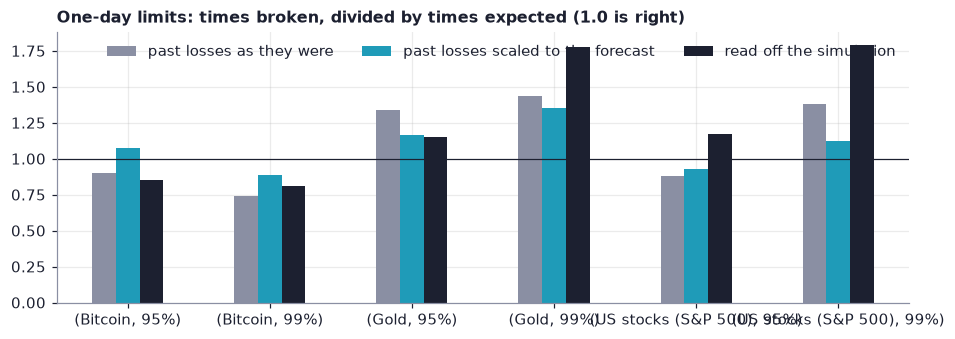

In [10]:
ratio = (
    limits.assign(ratio=limits["broken"] / limits["expected"])
    .xs(1, level="days ahead")["ratio"]
    .unstack("method")
)
ax = ratio.plot.bar(rot=0, color=[MUTED, ACCENT, INK], figsize=(10, 3.2))
ax.axhline(1.0, color=INK, lw=0.8)
ax.set(title="One-day limits: times broken, divided by times expected (1.0 is right)", xlabel="")
ax.legend(ncol=3);

In [11]:
# The claim in the summary, checked: how many limits passed, by method.
passed = limits.groupby(level="method")["reliable"].agg(["sum", "count"])
passed.columns = ["passed", "tested"]
print(passed.to_string())
failed = limits[limits["shown in the app"] & ~limits["reliable"]]
print(f"\nlimits shown in the app that failed their test: {len(failed)}")
if len(failed):
    print(failed[["periods", "broken", "expected"]].to_string())

                                    passed  tested
method                                            
past losses as they were                12      12
past losses scaled to the forecast      12      12
read off the simulation                 11      12

limits shown in the app that failed their test: 0


Bars near 1.0 are limits that held as stated. Well above 1.0, the limit was too tight
and was broken too often; well below, it was too loose. The app shows, for each
market and horizon, the method that did best here, and marks any limit that failed.

### The deepest falls on record

In [12]:
falls = pd.concat(
    {MARKETS[s]: pd.DataFrame(limit_scores[s]["drawdowns"]) for s in MARKETS}
).droplevel(1)
falls

,depth,peak_day,trough_day,recovered_day
Bitcoin,-0.77,2021-11-08,2022-11-21,2024-03-04
Bitcoin,-0.53,2021-04-13,2021-07-20,2021-10-19
Bitcoin,-0.53,2025-10-06,2026-06-30,NaN
Bitcoin,-0.28,2025-01-21,2025-04-08,2025-05-18
Bitcoin,-0.26,2024-03-13,2024-09-06,2024-11-06
Gold,-0.28,2026-01-28,2026-07-16,NaN
Gold,-0.21,2022-03-08,2022-10-20,2023-12-03
Gold,-0.16,2021-01-05,2021-03-30,2022-03-08
Gold,-0.12,2025-10-16,2025-11-04,2025-12-22
Gold,-0.08,2024-10-30,2024-11-14,2025-01-30


## What to take from this

- The size of a movement can be forecast to a useful degree, and three numbers do it
  as well as anything more elaborate tried here.
- A loss limit scaled to that forecast is the one that holds most often. Where a
  limit failed its test, the count above names it and the app marks it.
- The seven-day test uses weeks that do not overlap, so it has few of them. A 99%
  limit judged on that few is rough: read the "periods" column before trusting it.
- Gold is followed as PAX Gold, whose record starts in 2021, so its tests cover fewer
  years than the other two.